In [9]:
%pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


Đang load dữ liệu...
Đang train mô hình cho sản phẩm: HOBBIES_1_001 tại CA_1
Đang trích xuất đặc trưng (Features)...
Đang huấn luyện mô hình LightGBM...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[18]	training's rmse: 0.567417	valid_1's rmse: 1.24976


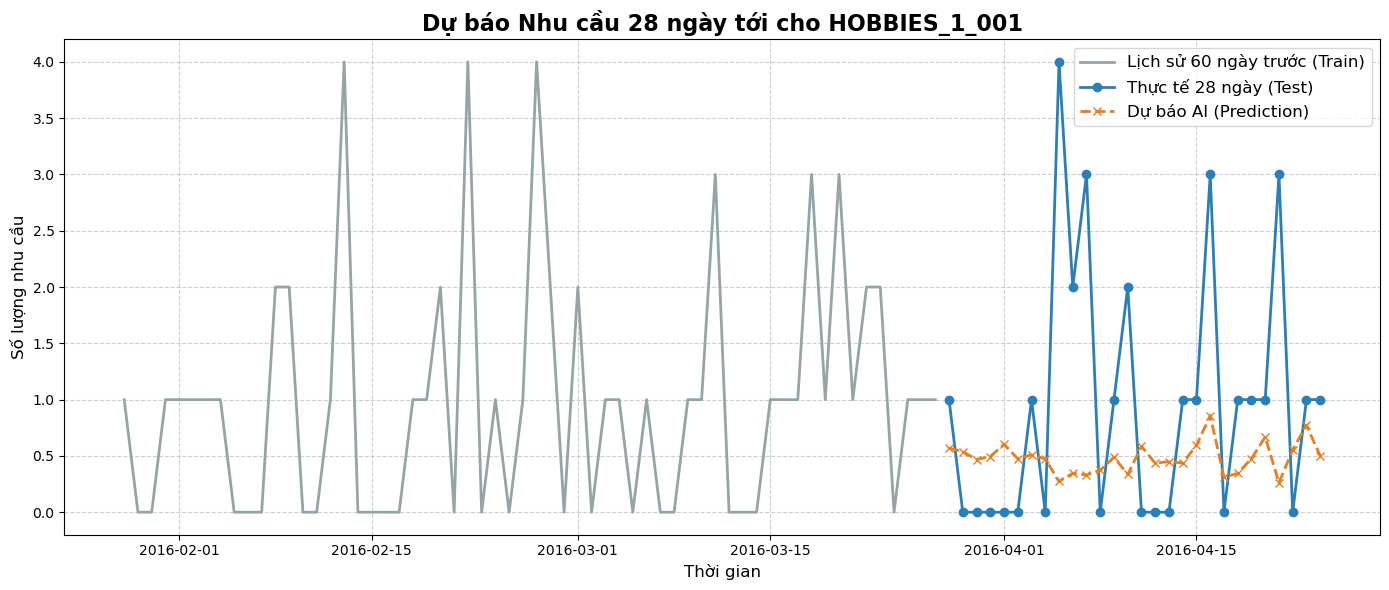

In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# 1. Load dữ liệu
PROCESSED_DIR = '../dataset/processed/'
print("Đang load dữ liệu...")
df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'master_data.parquet'))

# Lấy thử 1 mã sản phẩm để xây mô hình 
sample_item = df['item_id'].iloc[0]
sample_store = df['store_id'].iloc[0]
print(f"Đang train mô hình cho sản phẩm: {sample_item} tại {sample_store}")

df_item = df[(df['item_id'] == sample_item) & (df['store_id'] == sample_store)].copy()
df_item = df_item.sort_values('date').reset_index(drop=True)

# ==========================================
# FEATURE ENGINEERING (TẠO ĐẶC TRƯNG)
# ==========================================
print("Đang trích xuất đặc trưng (Features)...")
df_item['day'] = df_item['date'].dt.day
df_item['dayofweek'] = df_item['date'].dt.dayofweek
df_item['is_weekend'] = df_item['dayofweek'].isin([5, 6]).astype(int)

df_item['lag_7'] = df_item['demand'].shift(7)
df_item['lag_14'] = df_item['demand'].shift(14)
df_item['lag_28'] = df_item['demand'].shift(28)

df_item['rolling_mean_7'] = df_item['demand'].shift(1).rolling(7).mean()
df_item['rolling_std_7'] = df_item['demand'].shift(1).rolling(7).std()

# [SỬA LỖI Ở ĐÂY]: Chỉ drop NaN ở các cột Lag/Rolling
cols_to_check = ['lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7']
df_item = df_item.dropna(subset=cols_to_check)

# ==========================================
# TRAIN MÔ HÌNH LIGHTGBM
# ==========================================
print("Đang huấn luyện mô hình LightGBM...")
# Chia tập Train (Quá khứ) và Test (28 ngày cuối)
train_data = df_item.iloc[:-28]
test_data = df_item.iloc[-28:]

features = ['day', 'dayofweek', 'is_weekend', 'wday', 'month', 'snap_CA', 'snap_TX', 'snap_WI', 
            'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7']
target = 'demand'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

params = {
    'objective': 'tweedie', 
    'tweedie_variance_power': 1.1,
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

train_set = lgb.Dataset(X_train, y_train)
test_set = lgb.Dataset(X_test, y_test, reference=train_set)

model = lgb.train(
    params, 
    train_set, 
    num_boost_round=500, 
    valid_sets=[train_set, test_set],
    callbacks=[lgb.early_stopping(stopping_rounds=50)] # Giúp model tự dừng khi không tốt lên
)

# ==========================================
# DỰ BÁO VÀ VẼ BIỂU ĐỒ
# ==========================================
y_pred = model.predict(X_test)

plt.figure(figsize=(14, 6))
plt.plot(train_data['date'].iloc[-60:], train_data['demand'].iloc[-60:], label='Lịch sử 60 ngày trước (Train)', color='#95a5a6', linewidth=2)
plt.plot(test_data['date'], y_test, label='Thực tế 28 ngày (Test)', color='#2980b9', marker='o', linewidth=2)
plt.plot(test_data['date'], y_pred, label='Dự báo AI (Prediction)', color='#e67e22', linestyle='--', marker='x', linewidth=2)

plt.title(f"Dự báo Nhu cầu 28 ngày tới cho {sample_item}", fontsize=16, fontweight='bold')
plt.xlabel("Thời gian", fontsize=12)
plt.ylabel("Số lượng nhu cầu", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

1. Đang load dữ liệu Features...
2. Đang chuẩn bị dữ liệu cho: 1437 tại 0
3. Đang đưa vào Học máy...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	training's rmse: 0.494228	valid_1's rmse: 1.21756


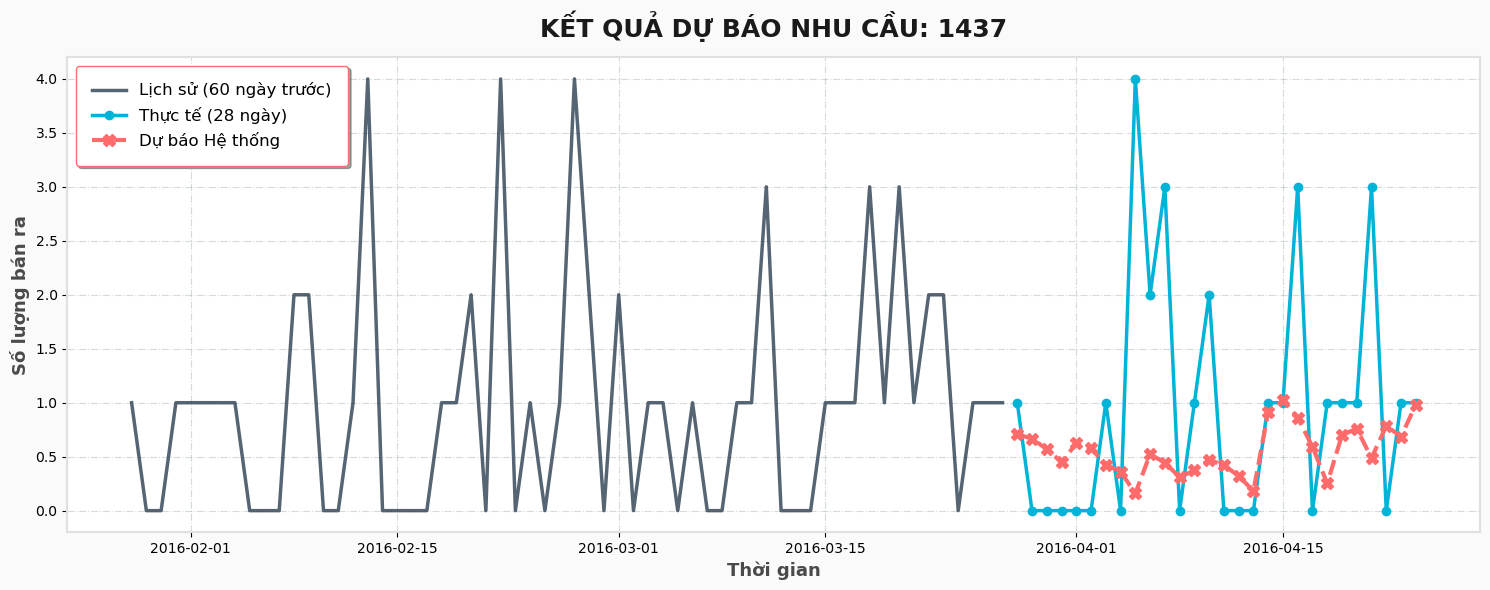

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# 1. Load dữ liệu đã trích xuất ĐẦY ĐỦ đặc trưng (Giá + Sự kiện)
PROCESSED_DIR = '../dataset/processed/'
print("1. Đang load dữ liệu Features...")
df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'featured_data.parquet'))

# Chọn 1 mặt hàng để mô phỏng (Bạn có thể đổi mã khác)
sample_item = df['item_id'].iloc[0]
sample_store = df['store_id'].iloc[0]
print(f"2. Đang chuẩn bị dữ liệu cho: {sample_item} tại {sample_store}")

df_item = df[(df['item_id'] == sample_item) & (df['store_id'] == sample_store)].copy()
df_item = df_item.sort_values('date').reset_index(drop=True)

# 3. Tạo nhanh các biến Trễ (Lag) và Trượt (Rolling) cho riêng mặt hàng này
df_item['lag_7'] = df_item['demand'].shift(7)
df_item['lag_14'] = df_item['demand'].shift(14)
df_item['rolling_mean_7'] = df_item['demand'].shift(1).rolling(7).mean()

# Chỉ xóa những dòng bị NaN do Lag tạo ra ở những ngày đầu tiên
cols_to_check = ['lag_7', 'lag_14', 'rolling_mean_7']
df_item = df_item.dropna(subset=cols_to_check)

# ==========================================
# HUẤN LUYỆN MÔ HÌNH (LIGHTGBM - TWEEDIE)
# ==========================================
print("3. Đang đưa vào Học máy...")
# Chia tập Train (Quá khứ) và Test (28 ngày cuối cùng)
train_data = df_item.iloc[:-28]
test_data = df_item.iloc[-28:]

# Đưa TẤT CẢ vũ khí vào cho máy học (Bao gồm Giá và Sự kiện)
features = [
    'day', 'is_weekend', 'snap_CA', 'snap_TX', 'snap_WI',  # Thời gian & Trợ cấp
    'sell_price', 'price_discount', 'price_momentum',      # Đặc trưng Giá
    'event_name_1',                                        # Đặc trưng Sự kiện lễ tết
    'lag_7', 'lag_14', 'rolling_mean_7'                    # Đặc trưng Chu kỳ
]
target = 'demand'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

# Cấu hình "bộ não" LightGBM chuyên trị hàng bán chậm (Tweedie)
params = {
    'objective': 'tweedie', 
    'tweedie_variance_power': 1.1,
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'force_col_wise': True
}

# Khai báo cho model biết cột 'event_name_1' là dạng Phân loại (Category)
categorical_features = ['event_name_1']

train_set = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
test_set = lgb.Dataset(X_test, y_test, reference=train_set, categorical_feature=categorical_features)

model = lgb.train(
    params, 
    train_set, 
    num_boost_round=600, 
    valid_sets=[train_set, test_set],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# ==========================================
# DỰ BÁO VÀ VẼ BIỂU ĐỒ BÁO CÁO 
# ==========================================
y_pred = model.predict(X_test)

# ĐỊNH DẠNG BIỂU ĐỒ SẮC NÉT, RỰC RỠ
fig, ax = plt.subplots(figsize=(15, 6), facecolor='#FAFAFA')
ax.set_facecolor('#FFFFFF')

# Vẽ đường Lịch sử (Quá khứ) - Màu Tím than mượt mà
ax.plot(train_data['date'].iloc[-60:], train_data['demand'].iloc[-60:], 
        label='Lịch sử (60 ngày trước)', color='#2C3E50', linewidth=2.5, alpha=0.8)

# Vẽ đường Thực tế (Test) - Màu Xanh ngọc bích nổi bật
ax.plot(test_data['date'], y_test, 
        label='Thực tế (28 ngày)', color='#00B4D8', marker='o', markersize=6, linewidth=2.5)

# Vẽ đường Dự báo AI - Màu Cam rực rỡ, sống động
ax.plot(test_data['date'], y_pred, 
        label='Dự báo Hệ thống', color='#FF6B6B', linestyle='--', marker='X', markersize=8, linewidth=3)

# Trang trí chữ và khung
ax.set_title(f"KẾT QUẢ DỰ BÁO NHU CẦU: {sample_item}", fontsize=18, fontweight='900', color='#1A1A1A', pad=15)
ax.set_xlabel("Thời gian", fontsize=13, fontweight='bold', color='#4A4A4A')
ax.set_ylabel("Số lượng bán ra", fontsize=13, fontweight='bold', color='#4A4A4A')

# Tùy chỉnh Lưới (Grid) và viền
ax.grid(True, linestyle='-.', alpha=0.4, color='#95A5A6')
for spine in ax.spines.values():
    spine.set_edgecolor('#E0E0E0')
    spine.set_linewidth(1.5)

# Chú thích đẹp mắt
legend = ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True, borderpad=1)
legend.get_frame().set_facecolor('#FFFFFF')
legend.get_frame().set_edgecolor('#FF6B6B')

plt.tight_layout()
plt.show()